<a href="https://colab.research.google.com/github/nhahub/NHA-5-153/blob/youssef-tasks/notebooks/03_eda_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Employee Attrition - Milestone 1, Task 3: Data Visualization (EDA)

**Goal:** build the visual components of the EDA. Histograms, box plots and heatmaps that show how
attrition relates to employee characteristics.

**Input:** `employee_attriton_data_clean.csv` (Task 1 output, 49,000 rows, 0 missing, 0 duplicates)

| Section | Content |
|---|---|
| 1 | Setup & data loading |
| 2 | Target distribution (class imbalance) |
| 3 | Histograms: numeric features by attrition |
| 4 | Box & violin plots + outlier check |
| 5 | Attrition rate by categorical features |
| 6 | Engineered segments (tenure groups, salary bands, age groups) |
| 7 | Heatmaps: correlation & attrition-rate pivots |
| 8 | Pairwise relationships |
| 9 | Interactive Plotly visualizations |
| 10 | Key takeaways for the EDA report (Task 4) |

> The same figures are generated reproducibly by `python src/eda_pipeline.py` into `reports/figures/`.

## 1. Setup & data loading

In [1]:
# !pip install -q plotly seaborn   # uncomment on a fresh environment
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.io as pio
from scipy import stats

pio.renderers.default = "colab" if "google.colab" in sys.modules else "notebook_connected"
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100

TARGET = "Attrition"
NUMERIC_COLS = ["Age", "TenureYears", "PerformanceRating", "MonthlySalary"]
CATEGORICAL_COLS = ["Gender", "JobRole"]
PALETTE = {"No": "#4C72B0", "Yes": "#DD8452"}
ORDER = ["No", "Yes"]

In [2]:
# Works locally (repo root or notebooks/) and on Colab (falls back to GitHub raw file)
FILE = "employee_attriton_data_clean.csv"
RAW_URL = f"https://raw.githubusercontent.com/nhahub/NHA-5-153/main/{FILE}"
candidates = [Path(FILE), Path("..") / FILE]
src = next((p for p in candidates if p.exists()), RAW_URL)
df = pd.read_csv(src)
print("Loaded from:", src)
print("Shape:", df.shape)
df.head()

Loaded from: ..\employee_attriton_data_clean.csv
Shape: (49000, 8)


,EmployeeID,Age,Gender,JobRole,TenureYears,PerformanceRating,MonthlySalary,Attrition
0,23056,33.0,Female,Manager,1.0,1.0,9734.51,No
1,47703,33.0,Female,HR Specialist,5.0,4.0,7552.38,No
2,7424,45.0,Male,Manager,0.0,4.0,3931.63,No
3,34697,35.0,Non-Binary,Manager,2.0,3.0,7992.26,No
4,31490,42.0,Male,Manager,1.0,3.0,5215.60,Yes


In [3]:
# Sanity check: the cleaned data should have no missing values or duplicates
print("Missing values:", int(df.isna().sum().sum()))
print("Duplicate rows:", int(df.duplicated().sum()))
print("Unique EmployeeID:", df["EmployeeID"].is_unique)
df.describe().T.round(2)

Missing values: 0
Duplicate rows: 0
Unique EmployeeID: True


,count,mean,std,min,25%,50%,75%,max
EmployeeID,49000.0,25028.91,14430.28,1.00,12543.75,25034.50,37518.25,50000.0
Age,49000.0,36.27,7.83,18.00,32.00,35.00,41.00,79.0
TenureYears,49000.0,4.52,4.98,0.00,1.00,3.00,6.00,55.0
PerformanceRating,49000.0,3.15,0.95,1.00,3.00,3.00,4.00,5.0
MonthlySalary,49000.0,5999.24,1957.55,0.29,4675.98,5998.37,7310.86,15168.7


In [4]:
# Helper columns used only for EDA (the modelling dataset is built in the Task 2 notebook)
df["Attrition_Flag"] = (df[TARGET] == "Yes").astype(int)
df["TenureGroup"] = pd.cut(df["TenureYears"], bins=[-np.inf, 2, 5, 10, np.inf],
                           labels=["0-2 yrs", "3-5 yrs", "6-10 yrs", "10+ yrs"])
df["AgeGroup"] = pd.cut(df["Age"], bins=[17, 25, 35, 45, 55, np.inf],
                        labels=["18-25", "26-35", "36-45", "46-55", "56+"])
df["SalaryBand"] = pd.qcut(df["MonthlySalary"], q=4, labels=["Low", "Medium", "High", "Very High"])
df["Salary_Performance_Ratio"] = df["MonthlySalary"] / df["PerformanceRating"]

OVERALL_RATE = df["Attrition_Flag"].mean() * 100


def attrition_rate(data, by):
    g = data.groupby(by, observed=True)["Attrition_Flag"]
    out = pd.DataFrame({"Employees": g.size(), "Leavers": g.sum()})
    out["AttritionRate_%"] = (out["Leavers"] / out["Employees"] * 100).round(2)
    return out.reset_index()


def rate_bar(data, col, ax, sort=False):
    t = attrition_rate(data, col)
    t[col] = t[col].astype(str)
    if sort:
        t = t.sort_values("AttritionRate_%", ascending=False)
    sns.barplot(data=t, x=col, y="AttritionRate_%", color="#DD8452", ax=ax)
    for c in ax.containers:
        ax.bar_label(c, fmt="%.1f%%", fontsize=9)
    ax.axhline(OVERALL_RATE, ls="--", c="k", lw=1, label=f"Overall {OVERALL_RATE:.1f}%")
    ax.set_ylim(0, max(t["AttritionRate_%"].max(), OVERALL_RATE) * 1.25)
    ax.set_ylabel("Attrition rate (%)")
    ax.set_title(f"Attrition rate by {col}")
    ax.legend(loc="upper right", fontsize=8)
    ax.tick_params(axis="x", rotation=20)

## 2. Target distribution

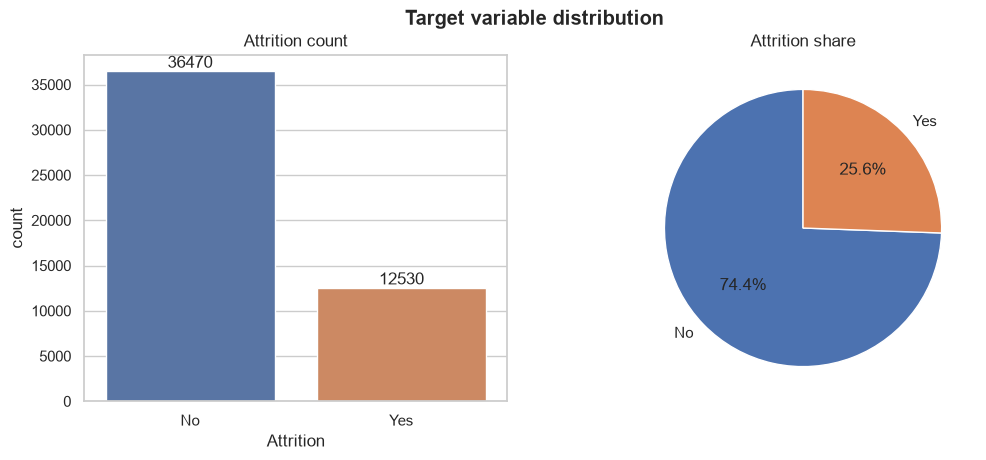

           Count  Percent
Attrition                
No         36470    74.43
Yes        12530    25.57


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
ax = sns.countplot(data=df, x=TARGET, order=ORDER, hue=TARGET, palette=PALETTE, legend=False, ax=axes[0])
for c in ax.containers:
    ax.bar_label(c, fmt="%d")
ax.set_title("Attrition count")
vc = df[TARGET].value_counts().reindex(ORDER)
axes[1].pie(vc, labels=vc.index, autopct="%1.1f%%", startangle=90,
            colors=[PALETTE[k] for k in vc.index], wedgeprops={"edgecolor": "white"})
axes[1].set_title("Attrition share")
plt.suptitle("Target variable distribution", fontweight="bold")
plt.show()
print(vc.to_frame("Count").assign(Percent=lambda x: (x.Count / x.Count.sum() * 100).round(2)))

**Interpretation:** about **25.6 % of employees left** (12,530 of 49,000), roughly 1 leaver for every 3 who stay.
The classes are **imbalanced**, so in Milestone 3 accuracy alone will be misleading (a model that always predicts
"No" scores 74 %). We should use stratified splits, look at recall / F1 / ROC-AUC, and try SMOTE or class weights.

## 3. Histograms: numeric features by attrition

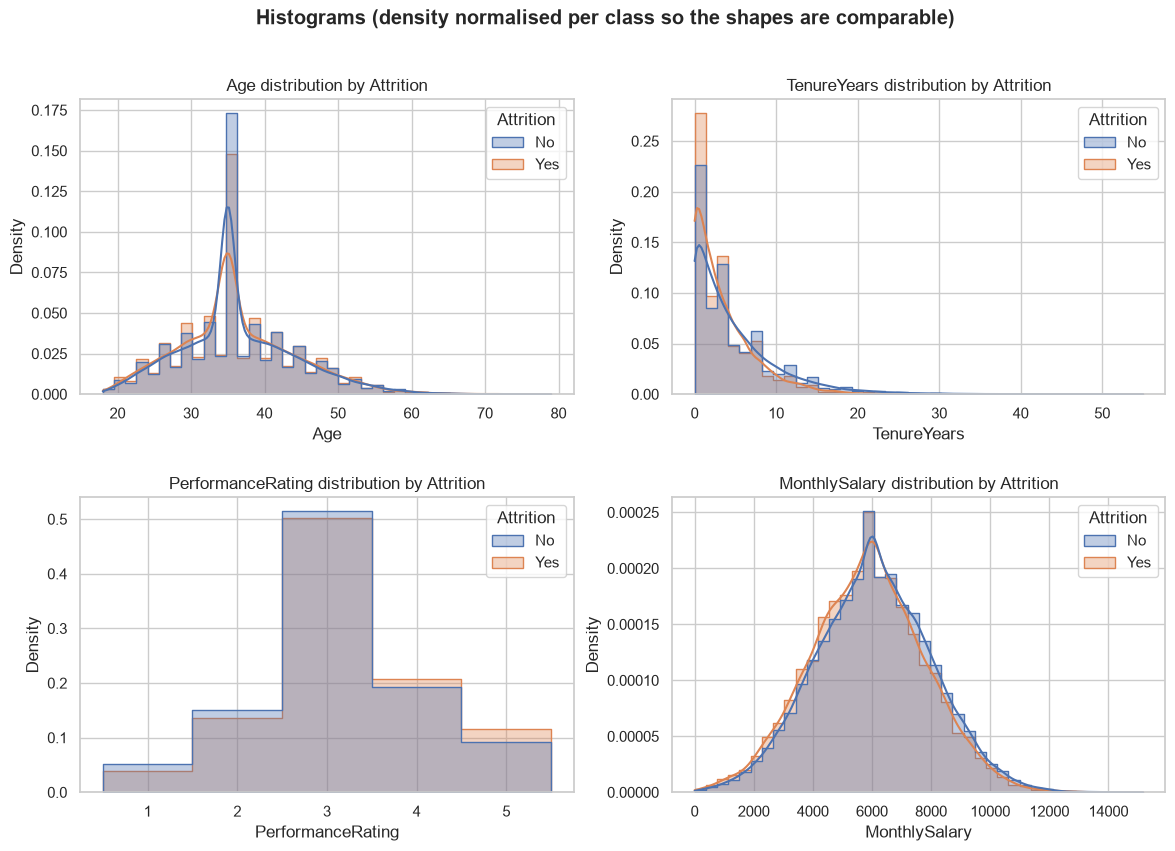

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, col in zip(axes.flat, NUMERIC_COLS):
    discrete = col == "PerformanceRating"
    sns.histplot(data=df, x=col, hue=TARGET, hue_order=ORDER, palette=PALETTE,
                 stat="density", common_norm=False, kde=not discrete, discrete=discrete,
                 element="step", alpha=0.35, bins="auto" if discrete else 40, ax=ax)
    ax.set_title(f"{col} distribution by Attrition")
plt.suptitle("Histograms (density normalised per class so the shapes are comparable)", fontweight="bold")
plt.subplots_adjust(hspace=0.35)
plt.show()

**Interpretation**
- **TenureYears** is strongly right-skewed (skew ≈ 2.0). Leavers are concentrated in the first 0-2 years, while
  stayers have a longer tail. This is the clearest visual separation of any feature.
- **MonthlySalary** is roughly normal. The leaver curve sits slightly **left** of the stayer curve, so leavers earn a bit less.
- **PerformanceRating**: leavers are **over-represented at ratings 4-5**, which is unexpected (see Section 5).
- **Age** distributions almost overlap, so age on its own does not separate the classes.
- ⚠️ The tall spikes at **Age = 35** and **MonthlySalary ≈ 6,000** come from **median imputation** in Task 1.
  They are artificial and should be noted in the report (an alternative is KNN or group-wise imputation).

## 4. Box plots, violin plots & outliers

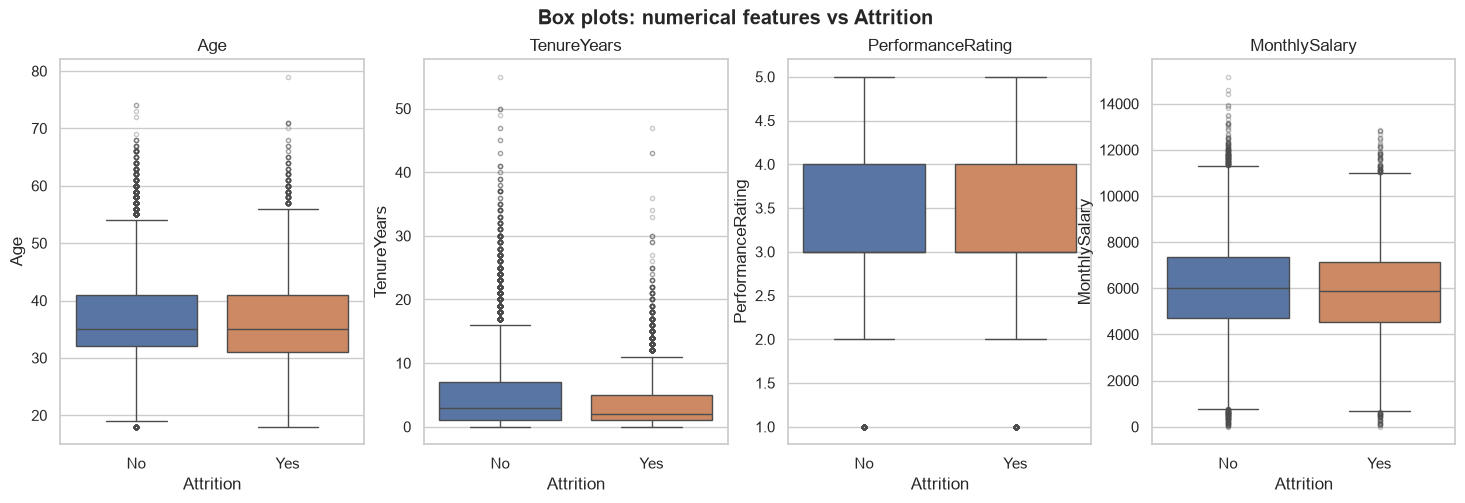

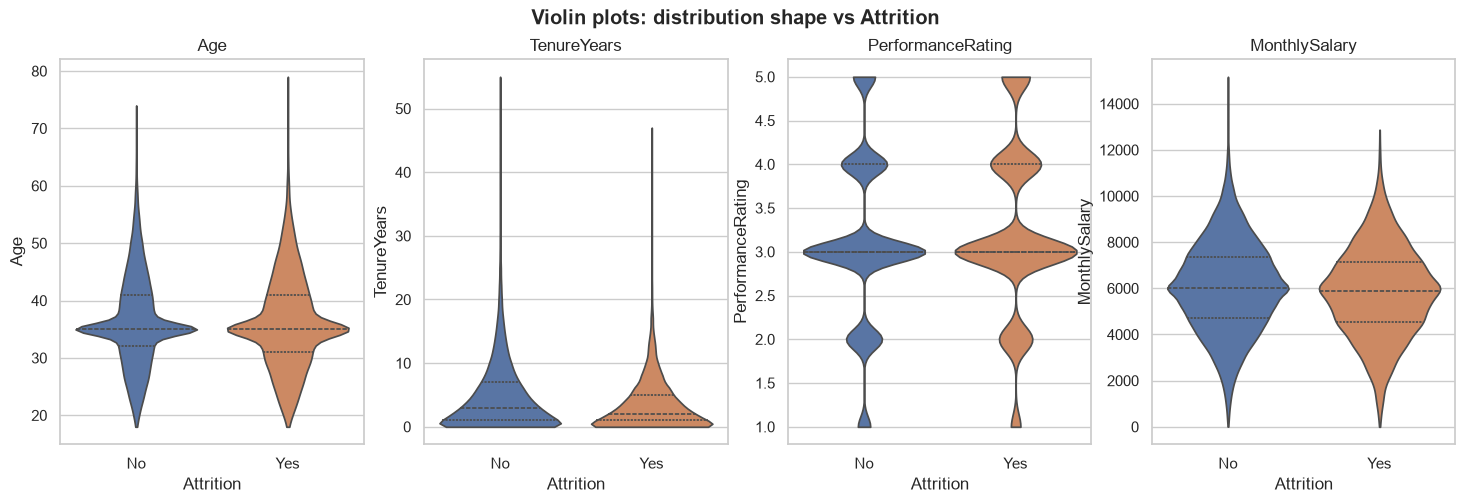

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, col in zip(axes, NUMERIC_COLS):
    sns.boxplot(data=df, x=TARGET, y=col, order=ORDER, hue=TARGET, palette=PALETTE,
                legend=False, flierprops={"marker": ".", "alpha": 0.3}, ax=ax)
    ax.set_title(col)
plt.suptitle("Box plots: numerical features vs Attrition", fontweight="bold")
plt.show()

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, col in zip(axes, NUMERIC_COLS):
    sns.violinplot(data=df, x=TARGET, y=col, order=ORDER, hue=TARGET, palette=PALETTE,
                   legend=False, inner="quartile", cut=0, ax=ax)
    ax.set_title(col)
plt.suptitle("Violin plots: distribution shape vs Attrition", fontweight="bold")
plt.show()

In [8]:
# Outlier count with the IQR rule (1.5 x IQR)
rows = []
for col in NUMERIC_COLS:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n = int(((df[col] < lo) | (df[col] > hi)).sum())
    rows.append({"Feature": col, "LowerFence": round(lo, 2), "UpperFence": round(hi, 2),
                 "Outliers": n, "Outliers_%": round(n / len(df) * 100, 2)})
pd.DataFrame(rows)

,Feature,LowerFence,UpperFence,Outliers,Outliers_%
0,Age,18.50,54.50,1120,2.29
1,TenureYears,-6.50,13.50,2940,6.00
2,PerformanceRating,1.50,5.50,2376,4.85
3,MonthlySalary,723.66,11263.18,328,0.67


In [9]:
# Numeric summary split by attrition
df.groupby(TARGET)[NUMERIC_COLS].agg(["mean", "median"]).round(2).T

Attrition                      No      Yes
Age               mean      36.30    36.19
                  median    35.00    35.00
TenureYears       mean       4.85     3.56
                  median     3.00     2.00
PerformanceRating mean       3.12     3.22
                  median     3.00     3.00
MonthlySalary     mean    6051.35  5847.54
                  median  5998.69  5900.92

**Interpretation**
- Median tenure is **2 years for leavers vs 3 for stayers** (mean 3.6 vs 4.9). Leavers also have a much narrower spread.
- Mean salary is **5,848 for leavers vs 6,051 for stayers** (about 3 % lower).
- **Outliers:** TenureYears has about 6 % above the 13.5-year fence (max 55 years, which is implausible next to a
  max age of 79), Age has about 2.3 % above 54.5, and MonthlySalary has 0.7 %, including near-zero values (min 0.29).
  They were **kept** for EDA because they are possible values, but tree models are robust to them and linear
  models may need capping or a log transform of `TenureYears` in Milestone 2.

## 5. Attrition rate by categorical features

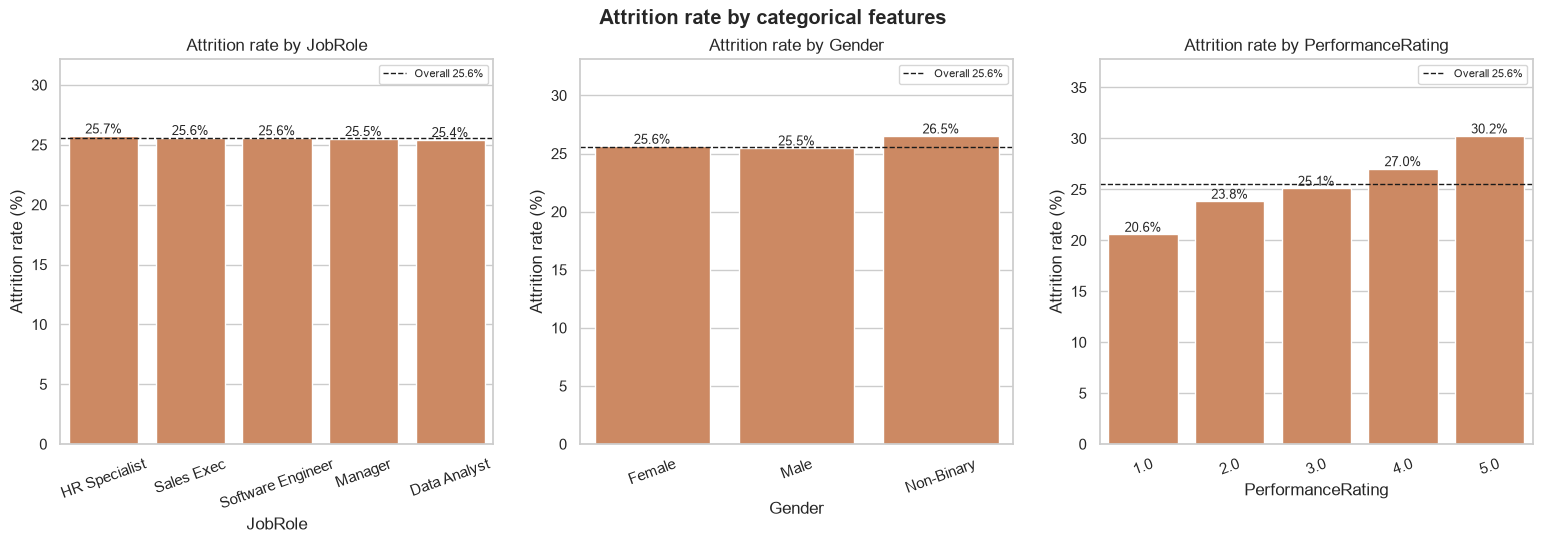

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(19, 5))
rate_bar(df, "JobRole", axes[0], sort=True)
rate_bar(df, "Gender", axes[1])
rate_bar(df, "PerformanceRating", axes[2])
plt.suptitle("Attrition rate by categorical features", fontweight="bold")
plt.show()

In [11]:
# Chi-square test of independence for each categorical feature
res = []
for col in CATEGORICAL_COLS + ["PerformanceRating"]:
    ct = pd.crosstab(df[col], df[TARGET])
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    cramers_v = np.sqrt(chi2 / (ct.values.sum() * (min(ct.shape) - 1)))
    res.append({"Feature": col, "Chi2": round(chi2, 2), "dof": dof, "p_value": round(p, 4),
                "Cramers_V": round(cramers_v, 4), "Significant": p < 0.05})
pd.DataFrame(res)

,Feature,Chi2,dof,p_value,Cramers_V,Significant
0,Gender,1.10,2,0.5773,0.0047,False
1,JobRole,0.25,4,0.9930,0.0022,False
2,PerformanceRating,110.62,4,0.0000,0.0475,True


**Interpretation**
- **JobRole** (25.4 %–25.7 %) and **Gender** (25.5 %–26.5 %) show **no meaningful difference** in attrition
  (chi-square p = 0.99 and 0.58). In this dataset, role and gender do **not** drive turnover.
- **PerformanceRating** has a clear **positive** trend: attrition rises from **20.6 % (rating 1) to 30.2 % (rating 5)**.
  Top performers leave the most. This is the classic "flight of talent" pattern and an important business insight,
  because the employees the company most wants to keep are the most likely to go.

## 6. Engineered segments: tenure groups, age groups, salary bands

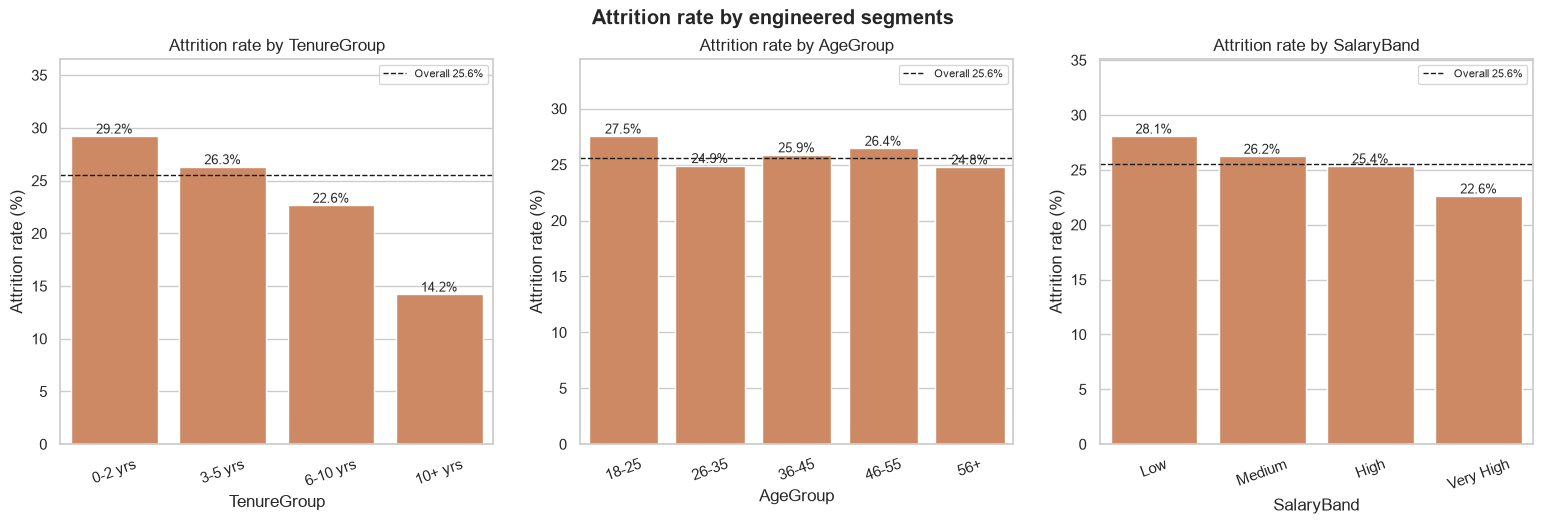

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(19, 5))
rate_bar(df, "TenureGroup", axes[0])
rate_bar(df, "AgeGroup", axes[1])
rate_bar(df, "SalaryBand", axes[2])
plt.suptitle("Attrition rate by engineered segments", fontweight="bold")
plt.show()

**Interpretation**
- **Tenure is the strongest driver.** Attrition is **29.2 %** for 0-2 years, 26.3 % for 3-5, 22.6 % for 6-10 and
  only **14.2 %** for 10+ years. Retention efforts (onboarding, mentoring, early career paths) should focus on the
  first two years. 45 % of the workforce is in the 0-2-year group.
- **Salary band**: attrition goes down steadily from **28.1 % (Low)** to **22.6 % (Very High)**, so pay matters.
- **Age group**: only weak effects. The youngest group (18-25) is slightly higher at 27.5 %.

## 7. Heatmaps

### 7a. Correlation matrix (numeric + one-hot encoded)

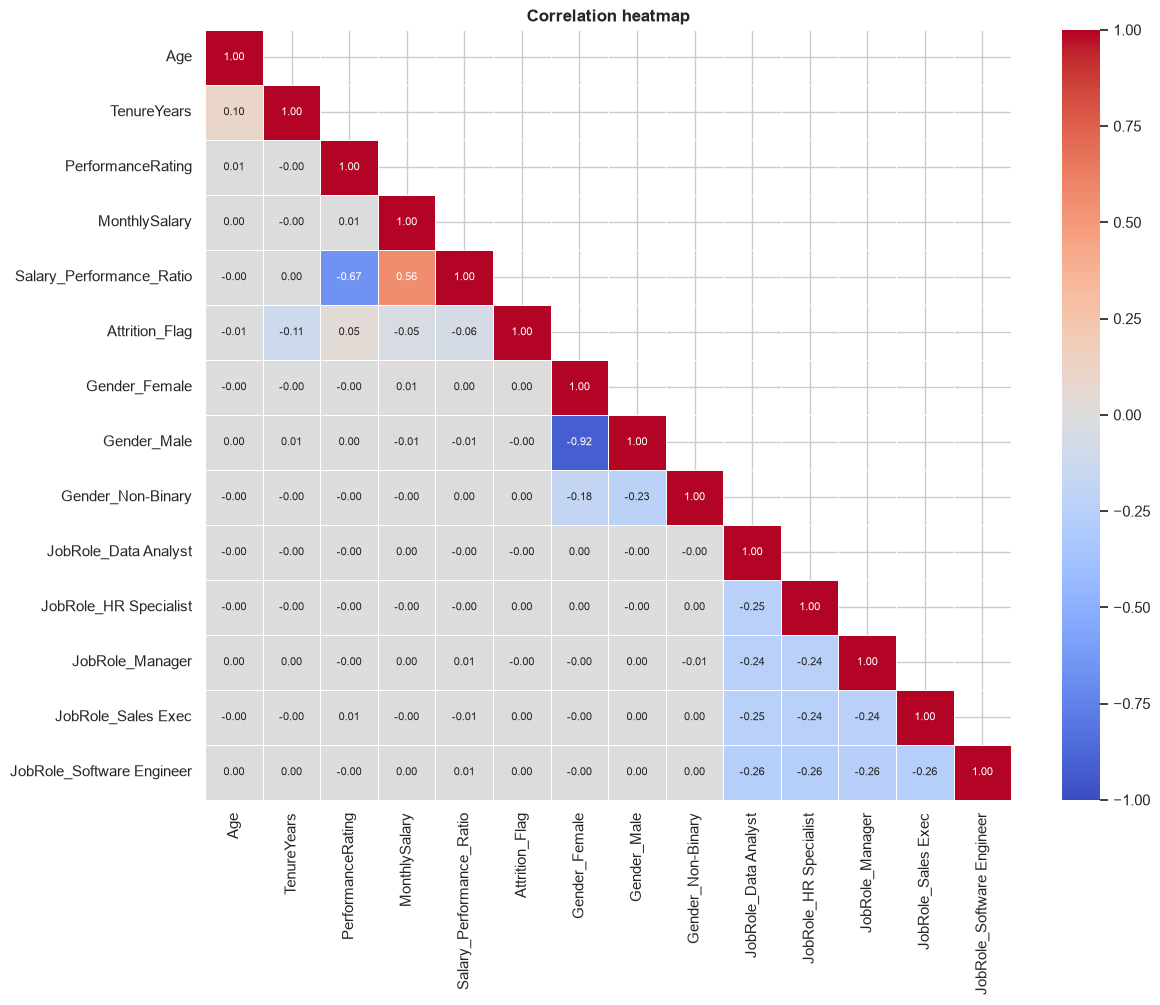

In [13]:
enc = pd.concat([df[NUMERIC_COLS + ["Salary_Performance_Ratio", "Attrition_Flag"]],
                 pd.get_dummies(df[CATEGORICAL_COLS], dtype=int)], axis=1)
corr = enc.corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
plt.figure(figsize=(13, 10))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1,
            linewidths=0.5, annot_kws={"size": 8})
plt.title("Correlation heatmap", fontweight="bold")
plt.show()

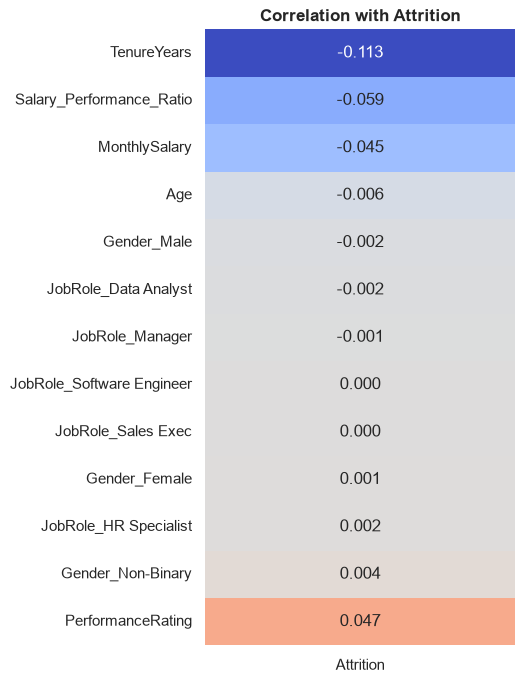

In [14]:
# Correlation of each feature with attrition (point-biserial = Pearson with a binary target)
tc = corr["Attrition_Flag"].drop("Attrition_Flag").sort_values()
plt.figure(figsize=(4, 8))
sns.heatmap(tc.to_frame("Attrition"), annot=True, fmt=".3f", cmap="coolwarm", center=0, cbar=False)
plt.title("Correlation with Attrition", fontweight="bold")
plt.show()

**Interpretation**
- Feature-to-target correlations are **weak overall** (|r| ≤ 0.11). Attrition is not linearly driven by any single
  variable, so **non-linear models and interaction features** (Milestone 2/3) will matter.
- Ranking: **TenureYears (−0.11)** > Salary_Performance_Ratio (−0.06) > PerformanceRating (+0.05) > MonthlySalary (−0.05).
  JobRole and Gender are about 0.
- **Multicollinearity:** the original features are almost independent of each other, which is good. The engineered
  `Salary_Performance_Ratio` is correlated with its parents (r = 0.56 / −0.67), and `Gender_Male` / `Gender_Female` are
  strongly negatively correlated (−0.92), which is why `drop_first=True` was used in the Task 2 encoding.

### 7b. Attrition-rate heatmaps (two-way segments)

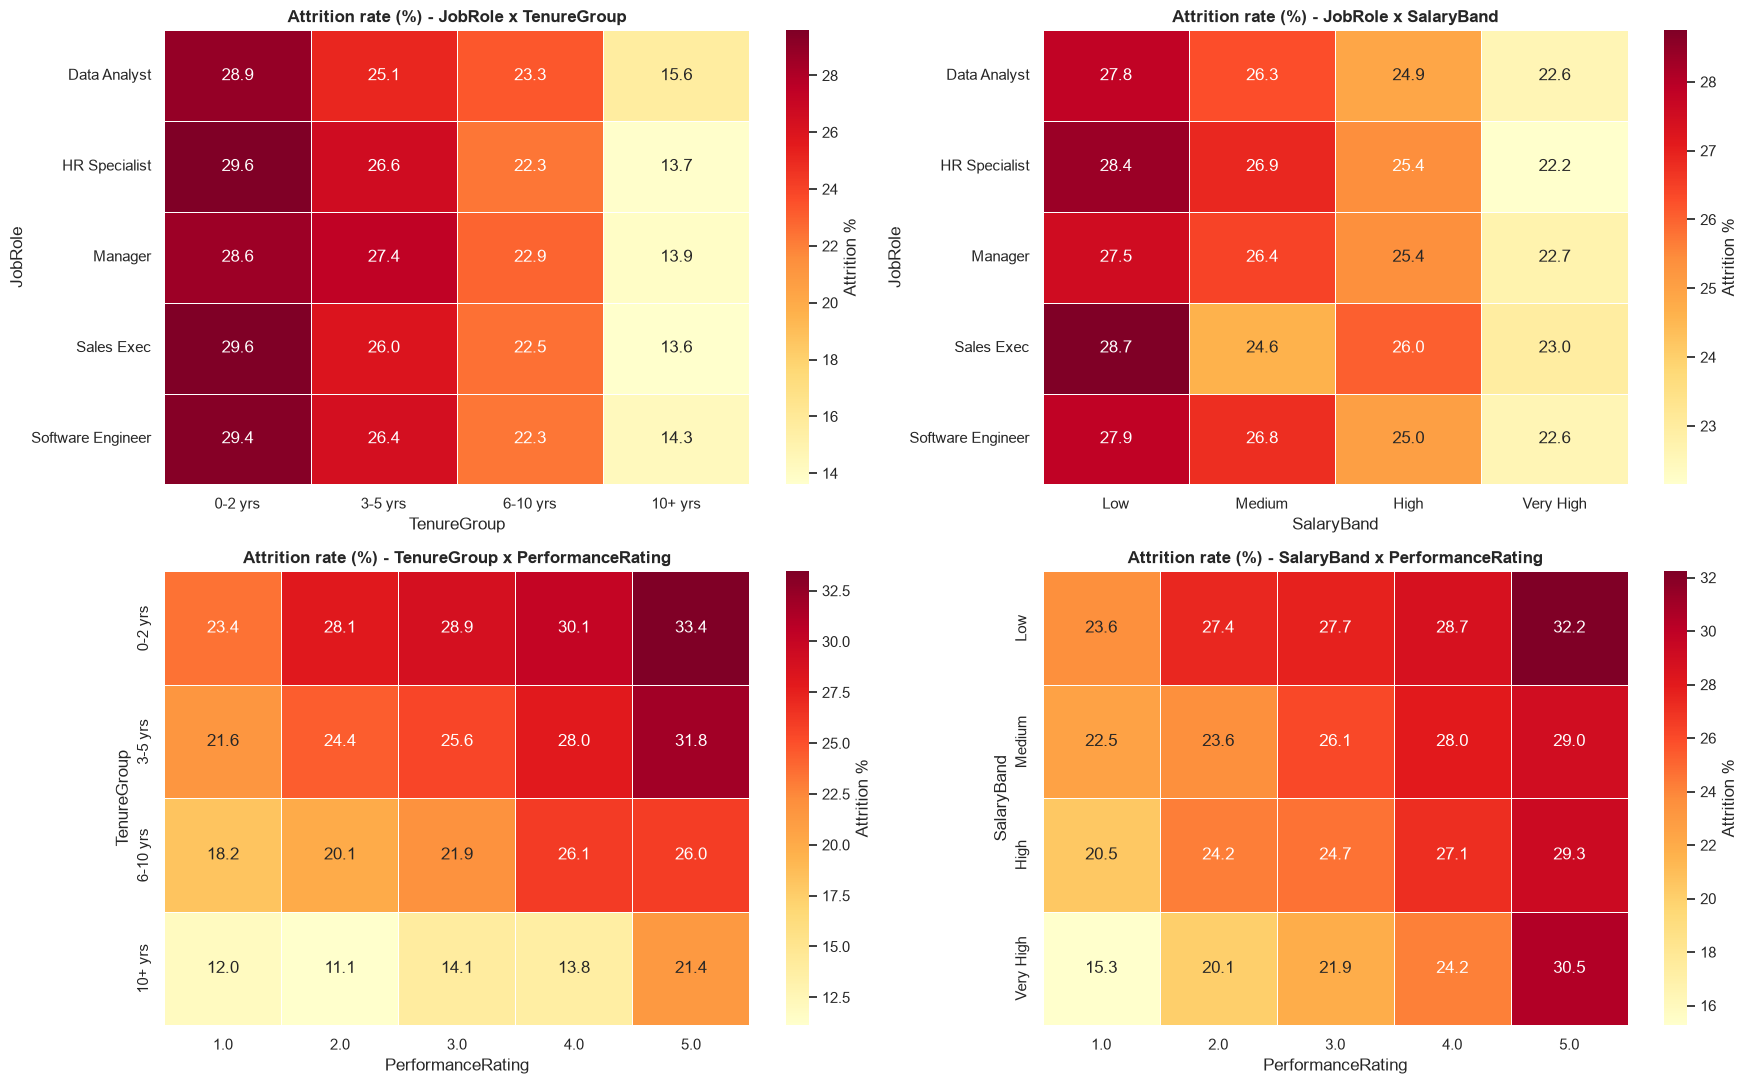

In [15]:
pivots = [("JobRole", "TenureGroup"), ("JobRole", "SalaryBand"),
          ("TenureGroup", "PerformanceRating"), ("SalaryBand", "PerformanceRating")]
fig, axes = plt.subplots(2, 2, figsize=(18, 11))
for ax, (r, c) in zip(axes.flat, pivots):
    pv = df.pivot_table(index=r, columns=c, values="Attrition_Flag", aggfunc="mean", observed=True) * 100
    sns.heatmap(pv, annot=True, fmt=".1f", cmap="YlOrRd", linewidths=0.5,
                cbar_kws={"label": "Attrition %"}, ax=ax)
    ax.set_title(f"Attrition rate (%) - {r} x {c}", fontweight="bold")
plt.tight_layout()
plt.show()

**Interpretation**
- **Tenure × Performance** is the most informative view. The highest-risk cell is **new (0-2 yrs) top performers
  (rating 5) at about 33 %**, and the lowest-risk cells are long-tenured low/medium performers (about 11-14 %).
  The two effects **add up**, which supports building interaction features.
- **Salary × Performance** checks the "underpaid high performer" idea. Low pay with rating 5 is the worst cell
  (**32.2 %**), but **even Very-High-paid top performers leave at 30.5 %**. Pay alone does **not** keep top talent.
  The salary effect is strongest for **low performers** (rating 1: 23.6 % Low pay vs 15.3 % Very High pay).
  For top performers, non-monetary levers (career growth, recognition, challenge) are likely needed.
- **JobRole × Tenure / Salary**: the tenure and salary gradients look the same for **every** role, which confirms that
  role is not a driver here.

## 8. Pairwise relationships (sample)

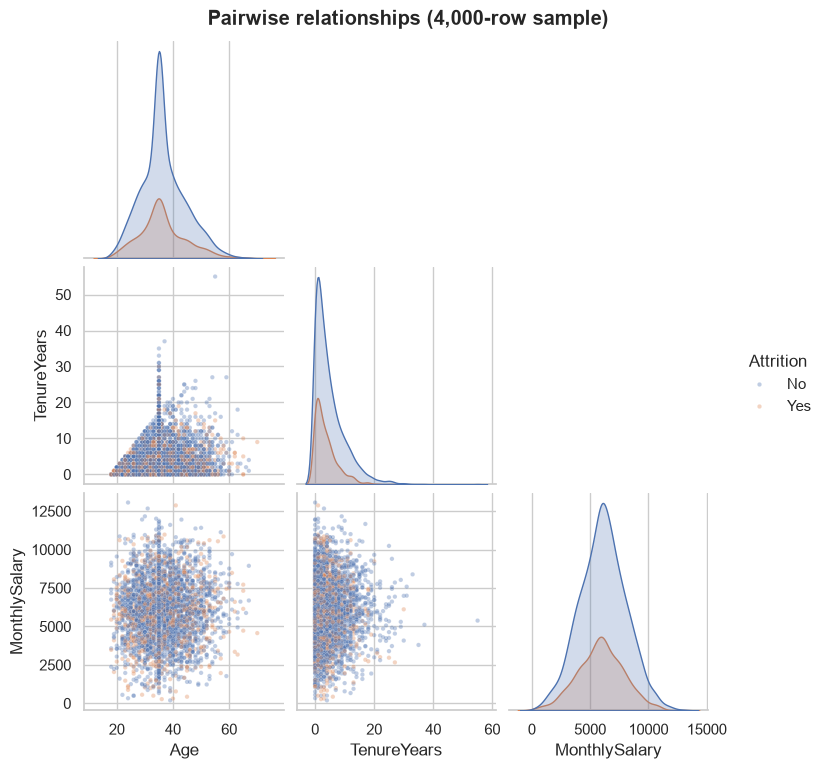

In [16]:
sample = df.sample(4000, random_state=42)
g = sns.pairplot(sample, vars=["Age", "TenureYears", "MonthlySalary"], hue=TARGET, hue_order=ORDER,
                 palette=PALETTE, corner=True, diag_kind="kde", plot_kws={"alpha": 0.35, "s": 10})
g.figure.suptitle("Pairwise relationships (4,000-row sample)", y=1.02, fontweight="bold")
plt.show()

**Interpretation:** there are no clear clusters separating leavers from stayers in any 2-D projection, which agrees with
the weak correlations. Age vs Tenure shows the expected lower-right triangle (tenure ≤ age − 18), confirming the
Task 1 consistency fix. The Age = 35 imputation line is also visible.

## 9. Interactive visualizations (Plotly)
Hover, zoom and click legend items to filter. On GitHub these cells do not render, so open the notebook in Colab
or open the HTML files in `reports/interactive/`.

In [17]:
px.scatter(df.sample(5000, random_state=42), x="TenureYears", y="MonthlySalary", color=TARGET,
           color_discrete_map=PALETTE, facet_col="JobRole", facet_col_wrap=3, opacity=0.5,
           hover_data=["Age", "PerformanceRating"],
           title="Monthly salary vs tenure by job role (5k sample)").show()

In [18]:
seg = attrition_rate(df, ["JobRole", "TenureGroup"])
seg["TenureGroup"] = seg["TenureGroup"].astype(str)
px.sunburst(seg, path=["JobRole", "TenureGroup"], values="Employees", color="AttritionRate_%",
            color_continuous_scale="YlOrRd",
            title="Headcount (size) & attrition rate (colour) by role and tenure").show()

In [19]:
perf = attrition_rate(df, ["PerformanceRating", "SalaryBand"])
perf["SalaryBand"] = perf["SalaryBand"].astype(str)
px.bar(perf, x="PerformanceRating", y="AttritionRate_%", color="SalaryBand", barmode="group",
       hover_data=["Employees", "Leavers"],
       title="Attrition rate by performance rating and salary band").show()

In [20]:
px.box(df.sample(10000, random_state=42), x="JobRole", y="MonthlySalary", color=TARGET,
       color_discrete_map=PALETTE, title="Monthly salary by job role and attrition (10k sample)").show()

## 10. Key takeaways for the EDA report (Task 4)

| # | Finding | Evidence | Implication |
|---|---|---|---|
| 1 | **Class imbalance**: 25.6 % attrition | Section 2 | Stratified split, SMOTE / class weights, F1 & ROC-AUC |
| 2 | **Tenure is the strongest driver** | 29.2 % (0-2 yrs) to 14.2 % (10+ yrs), r = −0.11, Cramér's V = 0.11 | Focus retention on the first 2 years; keep `TenureGroup` |
| 3 | **High performers leave more** | 20.6 % (rating 1) to 30.2 % (rating 5) | Flight-of-talent risk; recognition and career growth for top talent |
| 4 | **Lower pay means higher attrition** | 28.1 % (Low band) vs 22.6 % (Very High) | Pay competitiveness review; keep salary bands & salary/performance ratio |
| 5 | **Tenure × Performance compounds** | New top performers about 33 % | Interaction features are worth creating |
| 6 | **JobRole & Gender are not predictive** | χ² p = 0.99 / 0.58 | Candidates for removal in Milestone 2 feature selection |
| 7 | **Weak linear signal overall** | All abs(r) ≤ 0.11 | Prefer non-linear models (RF, GBM, XGBoost) |
| 8 | **Data-quality artefacts** | 21.7 % of rows have Age = 35 (median fill), salary spike at about 6k, tenure up to 55 yrs | Document; consider better imputation and capping |